# Pima Indians Diabetes 데이터 기초 분석

결측치, 중복값, 이상치를 확인하고 시각화합니다.

## 1. 데이터 불러오기

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = kagglehub.dataset_download("kumargh/pimaindiansdiabetescsv")
print("Path to dataset files:", path)

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
csv_path = os.path.join(path, csv_file)

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(csv_path, header=None, names=columns)

print(df.shape)
df.head()

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 8.89k/8.89k [00:00<00:00, 9.20MB/s]

Extracting files...
Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\kumargh\pimaindiansdiabetescsv\versions\1
(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. 결측치 확인

- 진짜 빈 값(NaN)이 있는지 확인
- 이 데이터셋은 결측치를 `0`으로 표기해놓은 경우가 많아 (예: 혈당 0은 있을 수 없음) 그 부분도 함께 확인

=== NaN 개수 ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


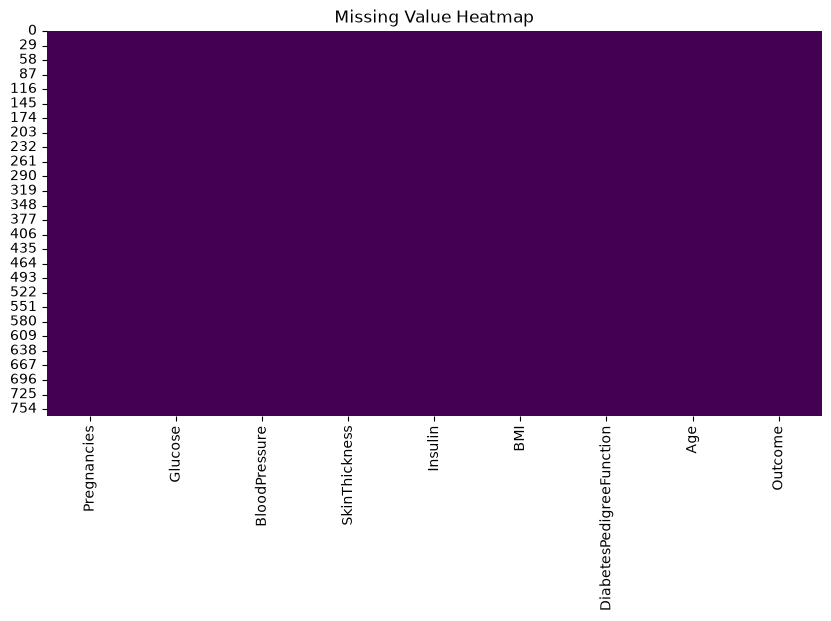

In [2]:
print("=== NaN 개수 ===")
print(df.isnull().sum())

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

=== 0 값 개수 (실질적 결측치로 의심되는 값) ===
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


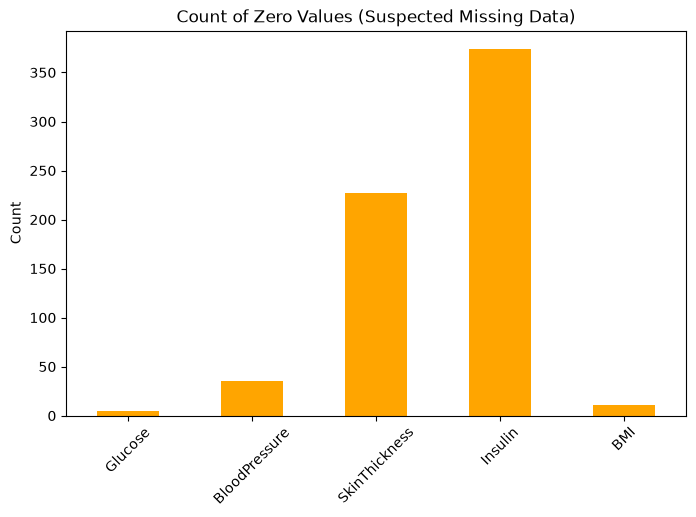

In [3]:
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("=== 0 값 개수 (실질적 결측치로 의심되는 값) ===")
zero_counts = (df[zero_as_missing_cols] == 0).sum()
print(zero_counts)

zero_counts.plot(kind="bar", figsize=(8, 5), color="orange")
plt.title("Count of Zero Values (Suspected Missing Data)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 3. 중복값 확인

In [4]:
dup_count = df.duplicated().sum()
print(f"중복된 행 개수: {dup_count}")

if dup_count > 0:
    print(df[df.duplicated()])

중복된 행 개수: 0


## 4. 이상치 확인 (박스플롯 + IQR)

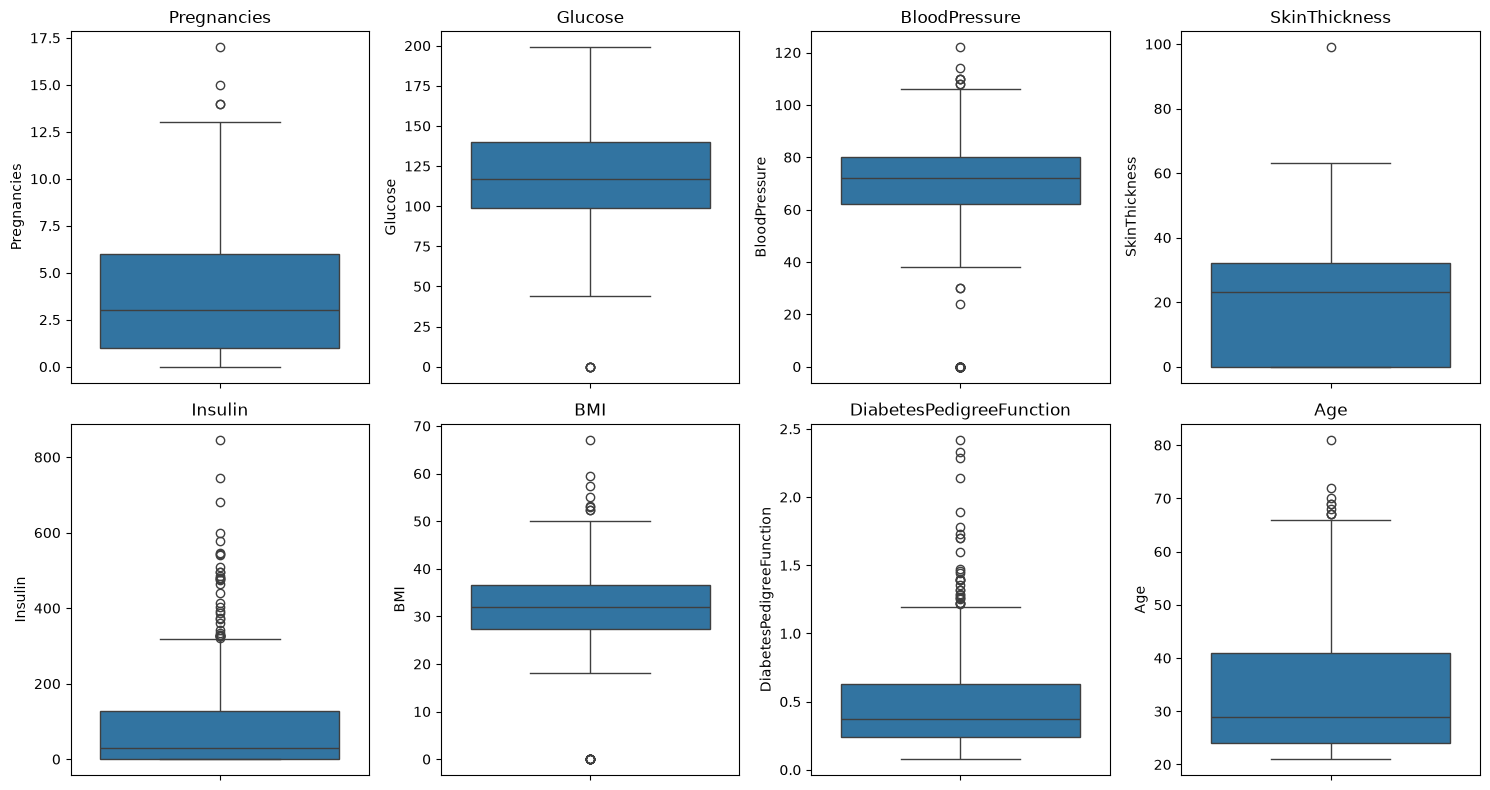

In [5]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(columns[:-1]):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [6]:
print("=== IQR 기준 이상치 개수 ===")
for col in columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)}개 (범위: {lower:.2f} ~ {upper:.2f})")

=== IQR 기준 이상치 개수 ===
Pregnancies: 4개 (범위: -6.50 ~ 13.50)
Glucose: 5개 (범위: 37.12 ~ 202.12)
BloodPressure: 45개 (범위: 35.00 ~ 107.00)
SkinThickness: 1개 (범위: -48.00 ~ 80.00)
Insulin: 34개 (범위: -190.88 ~ 318.12)
BMI: 19개 (범위: 13.35 ~ 50.55)
DiabetesPedigreeFunction: 29개 (범위: -0.33 ~ 1.20)
Age: 9개 (범위: -1.50 ~ 66.50)


## 5. 추가 시각화

- Outcome(당뇨병 여부) 분포
- 각 변수의 히스토그램
- 변수 간 상관관계
- 주요 변수와 Outcome의 관계

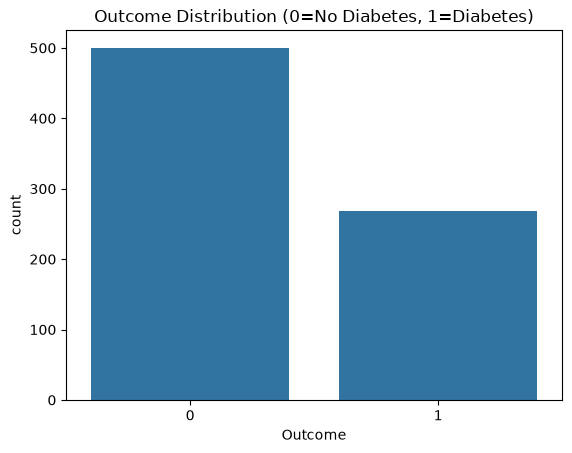

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [7]:
sns.countplot(x="Outcome", data=df)
plt.title("Outcome Distribution (0=No Diabetes, 1=Diabetes)")
plt.show()

print(df["Outcome"].value_counts(normalize=True))

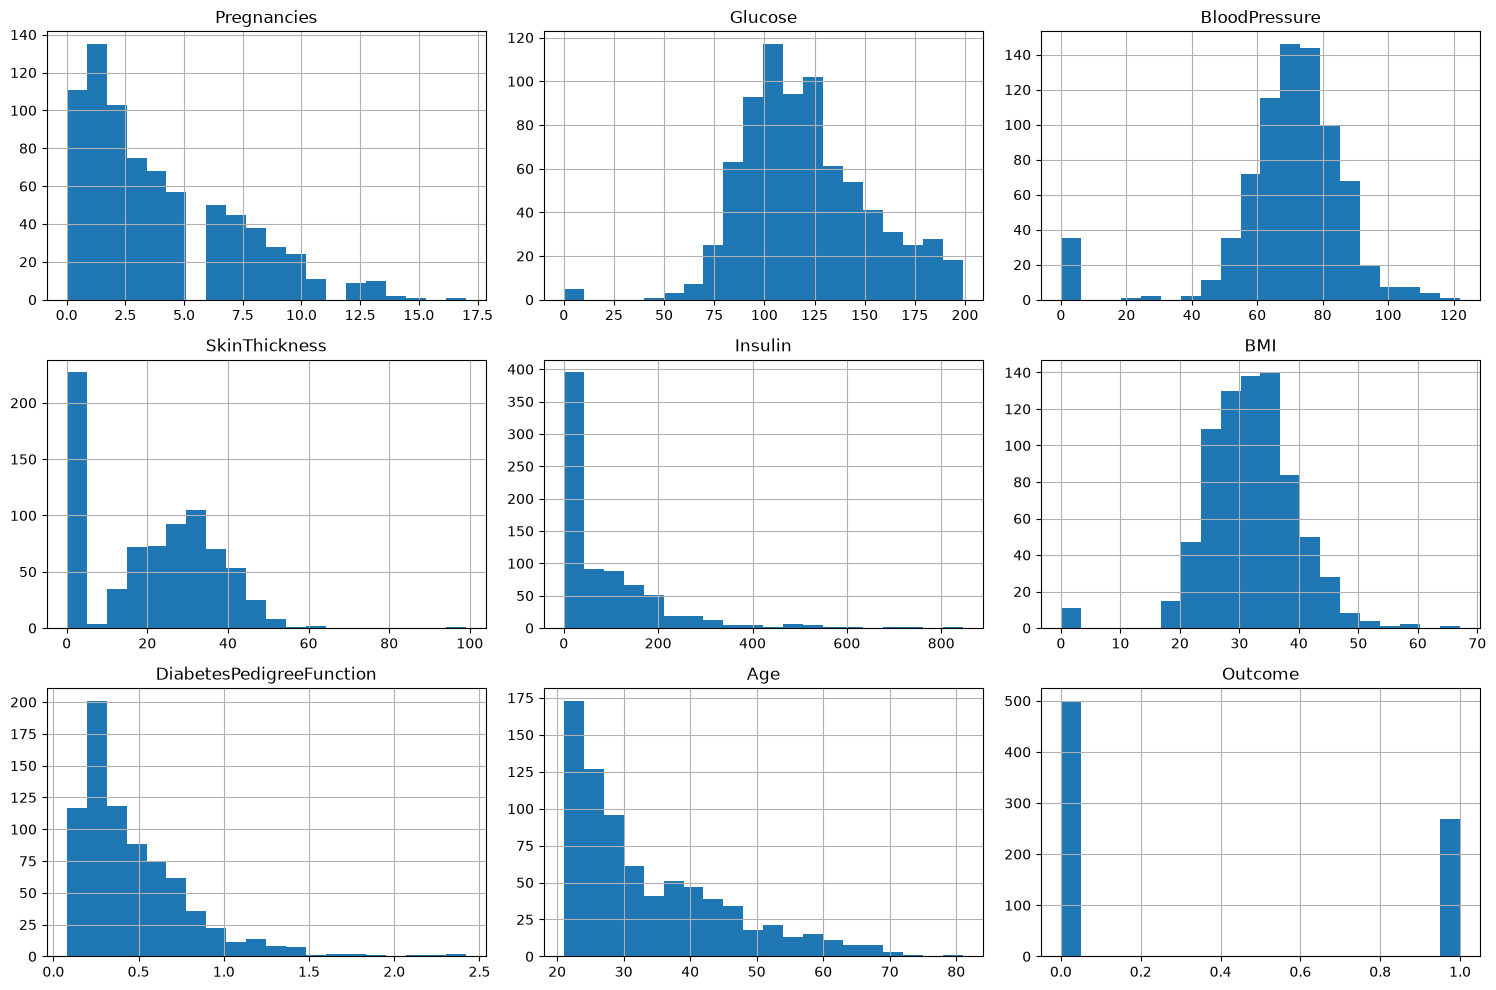

In [8]:
df.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

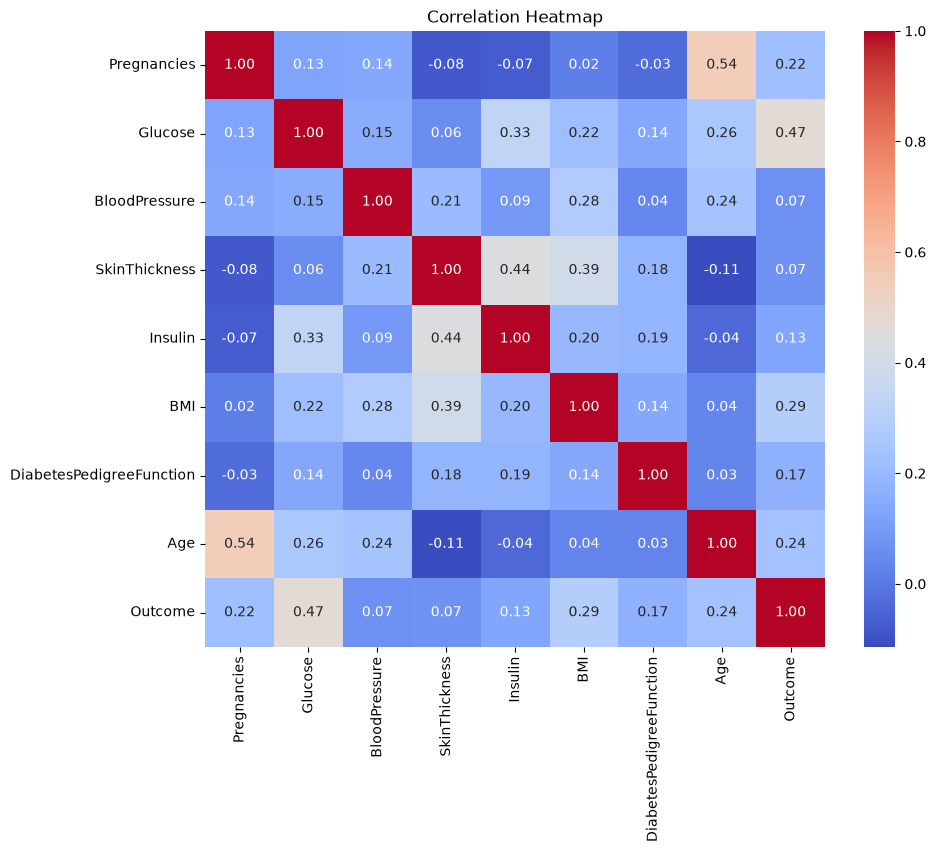

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

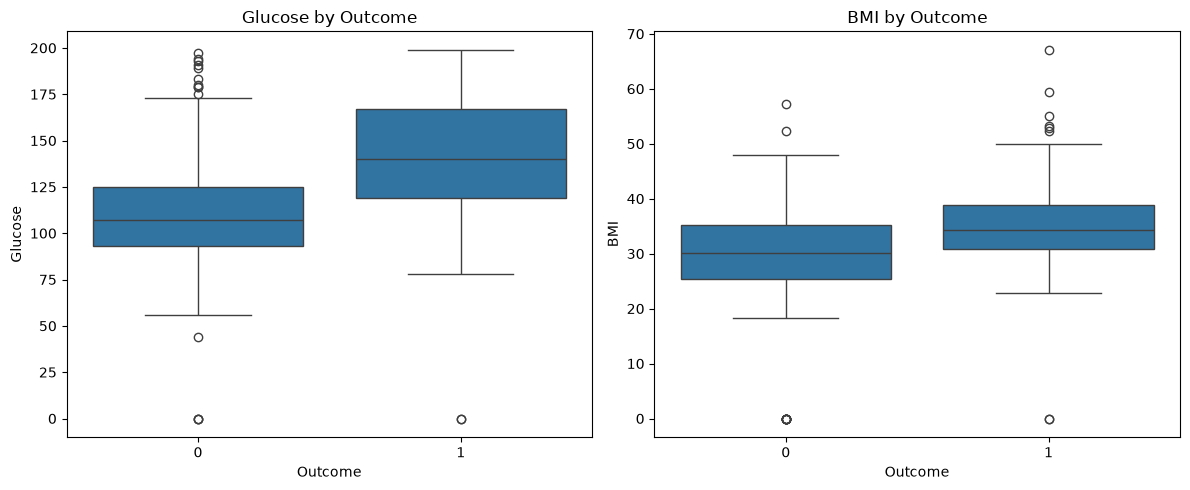

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x="Outcome", y="Glucose", data=df, ax=axes[0])
axes[0].set_title("Glucose by Outcome")

sns.boxplot(x="Outcome", y="BMI", data=df, ax=axes[1])
axes[1].set_title("BMI by Outcome")

plt.tight_layout()
plt.show()

## 6. 전처리: 0으로 표기된 결측치 대체

`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`의 0 값을 결측치로 바꾼 뒤,
각 컬럼의 **중앙값(median)**으로 채워서 모델 학습에 쓸 데이터를 만듭니다.

In [11]:
df_clean = df.copy()

for col in zero_as_missing_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("=== 전처리 후 0 값 개수 (모두 0이어야 정상) ===")
print((df_clean[zero_as_missing_cols] == 0).sum())

=== 전처리 후 0 값 개수 (모두 0이어야 정상) ===
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## 7. 예측 모델 만들기

`Outcome`(당뇨병 여부, 0/1)을 예측하는 이진 분류 모델을 만듭니다.
로지스틱 회귀와 랜덤포레스트 두 가지를 학습하고 성능을 비교합니다.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 로지스틱 회귀는 변수 스케일에 민감하므로 표준화 적용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")

학습 데이터: (614, 8), 테스트 데이터: (154, 8)


=== 로지스틱 회귀 결과 ===
정확도: 0.708
AUC: 0.813
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



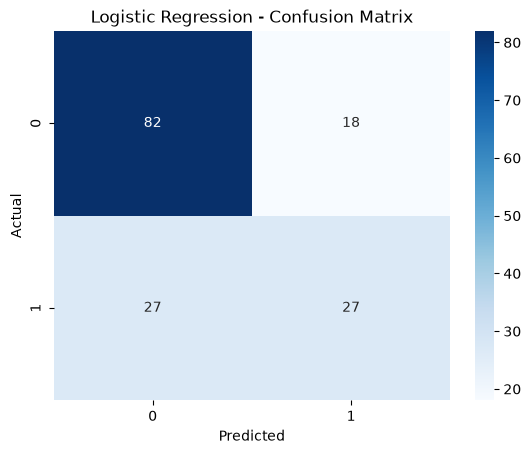

In [13]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

print("=== 로지스틱 회귀 결과 ===")
print(f"정확도: {accuracy_score(y_test, log_pred):.3f}")
print(f"AUC: {roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1]):.3f}")
print(classification_report(y_test, log_pred))

sns.heatmap(confusion_matrix(y_test, log_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== 랜덤포레스트 결과 ===
정확도: 0.740
AUC: 0.816
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



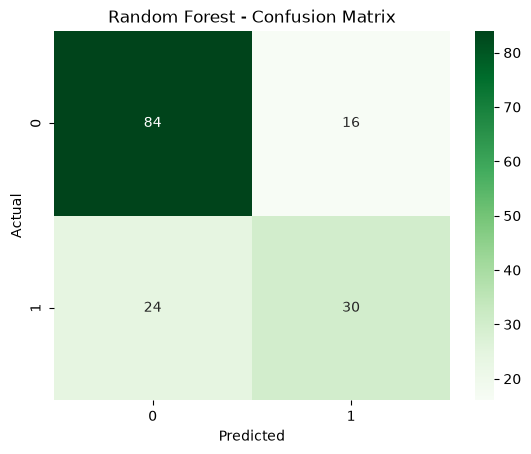

In [14]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== 랜덤포레스트 결과 ===")
print(f"정확도: {accuracy_score(y_test, rf_pred):.3f}")
print(f"AUC: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]):.3f}")
print(classification_report(y_test, rf_pred))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

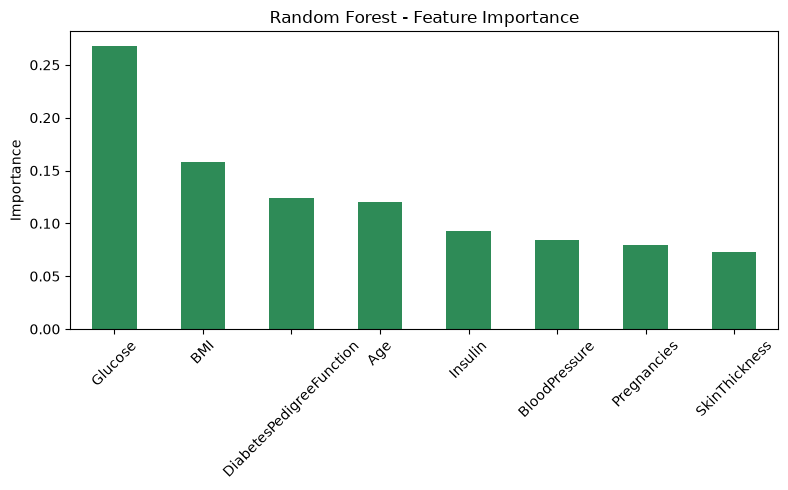

In [15]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.plot(kind="bar", color="seagreen")
plt.title("Random Forest - Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, log_pred), accuracy_score(y_test, rf_pred)],
    "AUC": [
        roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
    ],
})
results

,Model,Accuracy,AUC
0,Logistic Regression,0.707792,0.812963
1,Random Forest,0.740260,0.816111
